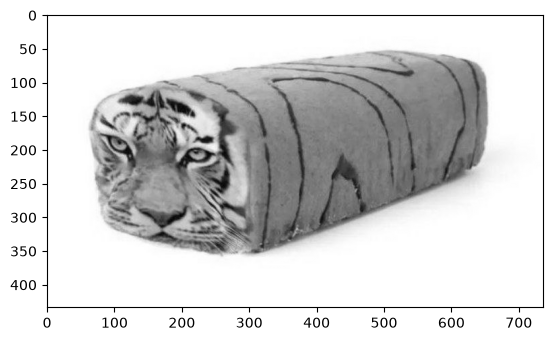

In [3]:
import numpy as np
import cv2
import copy
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity, mean_squared_error

def print_metrics(name, img_original, img_filtered):
    mse = mean_squared_error(img_original, img_filtered)
    (ssim, diff) = structural_similarity(img_original, img_filtered, full=True)
    print(f"{name:25s} | MSE: {mse:.2f} | SSIM: {ssim:.4f}")

image = cv2.imread('sar_1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(image_gray, cmap="gray")
plt.show()


***Зашумить изображение при помощи шума гаусса***

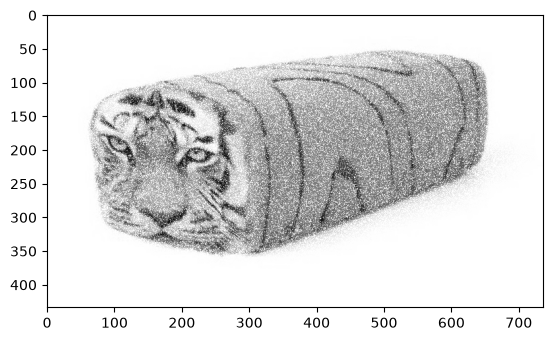

In [4]:
mean = 0
stddev = 100
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)
image_noise_gauss = cv2.add(image_gray, noise_gauss)
plt.imshow(image_noise_gauss, cmap="gray")
plt.show()

***Зашумить изображение при помощи постоянного шума***

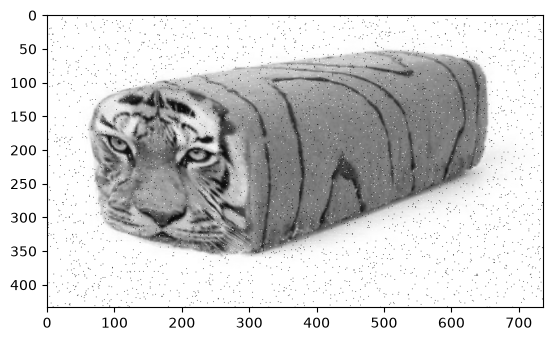

In [5]:
image_sp = copy.deepcopy(image_gray)
noise = np.random.randint(0, 101, size=(image_gray.shape[0], image_gray.shape[1]), dtype=int)
zeros_pixel = np.where(noise == 0)
ones_pixel = np.where(noise == 100)
image_sp[zeros_pixel] = 0
image_sp[ones_pixel] = 255
plt.imshow(image_sp, cmap="gray")
plt.show()

**Далее все фильтры применяются на шум Гаусса**

***Протестировать медианный фильтр***

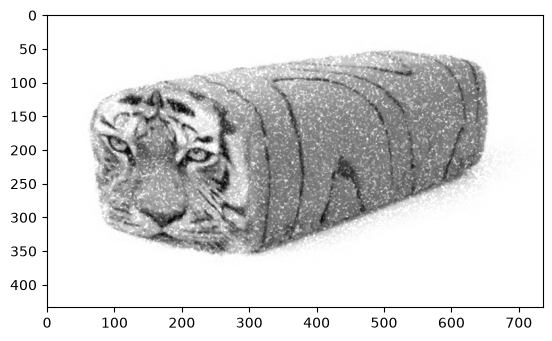

In [8]:
image_gauss_median = cv2.medianBlur(image_noise_gauss, 3)
plt.imshow(image_gauss_median, cmap="gray")
plt.show()

***Протестировать фильтр гаусса***

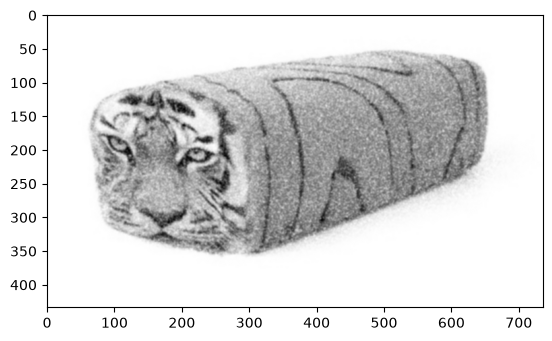

In [9]:
image_gauss_gauss = cv2.GaussianBlur(image_noise_gauss, (5, 5), 0)
plt.imshow(image_gauss_gauss, cmap="gray")
plt.show()

***Протестировать билатериальный фильтр***

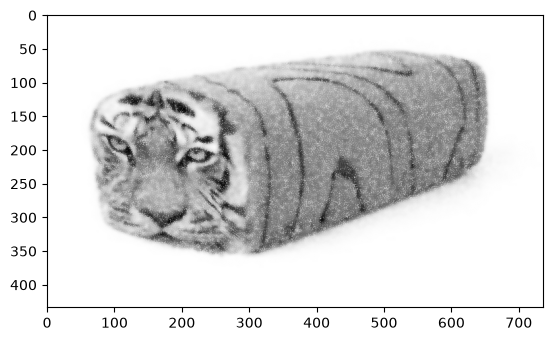

In [11]:
image_gauss_bilat = cv2.bilateralFilter(image_noise_gauss, 9, 75, 75)
plt.imshow(image_gauss_bilat, cmap="gray")
plt.show()

***Протестировать фильтр нелокальных средних с различными параметрами***

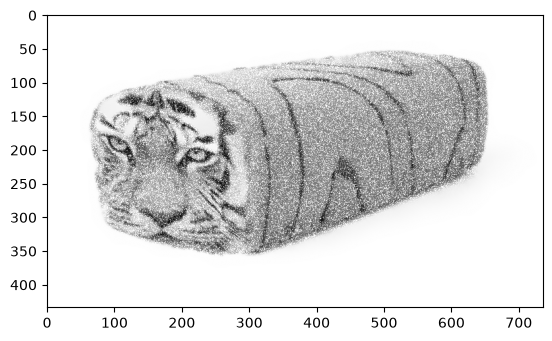

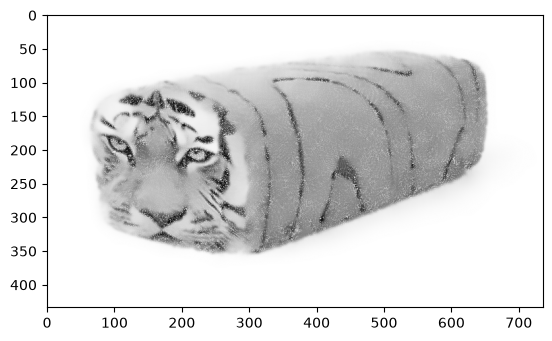

In [14]:
image_gauss_nlm13 = cv2.fastNlMeansDenoising(image_noise_gauss, h=13)
image_gauss_nlm32 = cv2.fastNlMeansDenoising(image_noise_gauss, h=32)
plt.imshow(image_gauss_nlm13, cmap="gray")
plt.show()
plt.imshow(image_gauss_nlm32, cmap="gray")
plt.show()

***Выяснить, какой фильтр показал лучший результат фильтрации шума***

In [16]:
print_metrics("Без фильтра (Исходник)", image_gray, image_noise_gauss)
print_metrics("Медианный фильтр", image_gray, image_gauss_median)
print_metrics("Фильтр Гаусса", image_gray, image_gauss_gauss)
print_metrics("Билатеральный фильтр", image_gray, image_gauss_bilat)
print_metrics("NL 13", image_gray, image_gauss_nlm13)
print_metrics("NL 32", image_gray, image_gauss_nlm32)

Без фильтра (Исходник)    | MSE: 1301.09 | SSIM: 0.6315
Медианный фильтр          | MSE: 376.40 | SSIM: 0.7318
Фильтр Гаусса             | MSE: 553.68 | SSIM: 0.8166
Билатеральный фильтр      | MSE: 557.80 | SSIM: 0.7568
NL 13                     | MSE: 1296.43 | SSIM: 0.6471
NL 32                     | MSE: 690.44 | SSIM: 0.7814


**Лучший по MSE - медианный**

**Лучший по SSIM - Гауссов**

**Лучший по визуальной оценке - Билатеральный**